# Part B — Feature Engineering & Linear Regression
**담당**: Donghyun (Part B) | **가설 H4**: 제목 스타일(객관 지표)이 조회수에 영향을 주며, 그 효과는 카테고리마다 다르다

**파이프라인**: ① Feature Engineering(객관 제목 파생) → ② Baseline OLS + 통계검증 4종 → ③ 카테고리별 분리 회귀

**누수 방지**: likes / dislikes / comment_count / days_on_trending / trending_lag 사용 안 함 (업로드 시점 미관측). category · publish 시간 · title · tags 만 사용.
> 노트북은 `LR/` 폴더에서 실행 가정 (입력 = `../EDA/`).

In [1]:
import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from patsy import dmatrices
from sklearn.metrics import r2_score, mean_squared_error

pd.set_option("display.max_columns", 50)
plt.rcParams["figure.dpi"] = 110

EDA = Path("../EDA")
OUT = Path(".")
df = pd.read_csv(EDA / "cleaned_USvideos.csv")
print("shape:", df.shape)
df.head(2)

shape: (6249, 17)


,video_id,title,category,views,log_views,likes,log_likes,dislikes,comment_count,log_comment_count,publish_hour,publish_weekday,trending_lag,days_on_trending,tags,comments_disabled,ratings_disabled
0,VYOjWnS4cMY,Childish Gambino - This Is America (Official V...,Music,225211923,19.232552,5023450,15.429628,343541,517232,13.156249,4,6,2,25,"Childish Gambino|""Rap""|""This Is America""|""mcDJ...",False,False
1,FlsCjmMhFmw,YouTube Rewind: The Shape of 2017 | #YouTubeRe...,Entertainment,149376127,18.821978,3093544,14.944828,1643059,810698,13.605652,17,2,1,8,"Rewind|""Rewind 2017""|""youtube rewind 2017""|""#Y...",False,False


## 0. 업로드 시각 병합 + 중복 영상 정리
- 시간 기반 split을 위해 원본 `USvideos.csv`에서 `publish_time`(업로드 UTC)을 `video_id`로 병합.
- 같은 영상이 여러 날 트렌딩 → 중복 행 존재 가능. 영상 1건 = 1행으로 정리(조회수 최대 행 유지).

In [2]:
# publish_time(업로드 시각) 병합
raw = pd.read_csv(EDA / "USvideos.csv", usecols=["video_id", "publish_time"])
raw = raw.drop_duplicates("video_id")
df = df.merge(raw, on="video_id", how="left")
df["publish_time"] = pd.to_datetime(df["publish_time"], utc=True, errors="coerce")
print("publish_time 결측:", df["publish_time"].isna().sum())

# 영상 단위 중복 제거 (조회수 최대 = 트렌딩 정점 기준)
dups = df.duplicated("video_id").sum()
df = df.sort_values("views").drop_duplicates("video_id", keep="last").reset_index(drop=True)
print(f"중복 제거 행 수: {dups}  ->  최종 영상 수: {len(df)}")

publish_time 결측: 0
중복 제거 행 수: 0  ->  최종 영상 수: 6249


## 1단계 — Feature Engineering (객관적 제목 파생변수)
모두 업로드 시점에 결정되는 변수 → 누수 없음.

| feature | 정의 | 자극성 해석 |
|---|---|---|
| title_len | 제목 글자 수 | 길이 |
| word_count | 단어 수 | 정보량 |
| caps_ratio | 대문자 비율 | 강조/외침 |
| exclaim_cnt | ! 개수 | 감정 강조 |
| question_cnt | ? 개수 | 호기심 유발 |
| has_number | 숫자 포함(0/1) | 리스트형 클릭베이트 |
| has_bracket | [] () 포함(0/1) | 태그형 제목 |
| tag_cnt | 태그 개수 | 노출 최적화 |

In [3]:
def caps_ratio(s):
    letters = [c for c in str(s) if c.isalpha()]
    if not letters:
        return 0.0
    return sum(c.isupper() for c in letters) / len(letters)

def tag_count(t):
    t = str(t).strip()
    if t in ("[none]", "", "nan"):
        return 0
    return len(t.split("|"))

t = df["title"].astype(str)
df["title_len"]    = t.str.len()
df["word_count"]   = t.str.split().str.len()
df["caps_ratio"]   = t.apply(caps_ratio)
df["exclaim_cnt"]  = t.str.count("!")
df["question_cnt"] = t.str.count(r"\?")
df["has_number"]   = t.str.contains(r"\d", regex=True).astype(int)
df["has_bracket"]  = t.str.contains(r"[\[\]\(\)]", regex=True).astype(int)
df["tag_cnt"]      = df["tags"].apply(tag_count)

title_feats = ["title_len","word_count","caps_ratio","exclaim_cnt",
               "question_cnt","has_number","has_bracket","tag_cnt"]
df[title_feats].describe().round(3)

,title_len,word_count,caps_ratio,exclaim_cnt,question_cnt,has_number,has_bracket,tag_cnt
count,6249.000,6249.000,6249.000,6249.000,6249.000,6249.000,6249.000,6249.000
mean,50.003,8.751,0.265,0.133,0.060,0.261,0.169,20.083
std,19.693,3.519,0.221,0.429,0.252,0.439,0.375,12.196
min,3.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,36.000,6.000,0.158,0.000,0.000,0.000,0.000,10.000
50%,48.000,8.000,0.195,0.000,0.000,0.000,0.000,20.000
75%,63.000,11.000,0.263,0.000,0.000,1.000,0.000,29.000
max,100.000,23.000,1.000,4.000,3.000,1.000,1.000,69.000


### 시간 변수 — publish_hour 구간 원-핫 (UTC)
원시 시간값은 23시↔0시 인접성을 무시하고 선형을 강제 → **6시간 4구간**으로 묶어 해석 명확화.
기준 그룹(reference) = `18-23` (drop). `publish_weekday`도 범주형으로 포함.

In [4]:
bins = [-0.1, 5.9, 11.9, 17.9, 23.9]
labels = ["00-05", "06-11", "12-17", "18-23"]
df["hour_bin"] = pd.cut(df["publish_hour"], bins=bins, labels=labels)
df["hour_bin"] = df["hour_bin"].cat.reorder_categories(labels)  # 18-23를 reference로 쓰기 위해 명시
print(df["hour_bin"].value_counts().sort_index())
print()
print("요일 분포:", dict(df["publish_weekday"].value_counts().sort_index()))

hour_bin
00-05    1147
06-11     700
12-17    2543
18-23    1859
Name: count, dtype: int64

요일 분포: {0: np.int64(970), 1: np.int64(1043), 2: np.int64(1091), 3: np.int64(1040), 4: np.int64(1026), 5: np.int64(536), 6: np.int64(543)}


In [5]:
# feature 테이블 저장
keep = ["video_id","category","log_views"] + title_feats + ["hour_bin","publish_weekday","publish_time"]
features = df[keep].copy()
features.to_csv(OUT / "features_partB.csv", index=False)
print("saved -> features_partB.csv", features.shape)
features.head(3)

saved -> features_partB.csv (6249, 14)


,video_id,category,log_views,title_len,word_count,caps_ratio,exclaim_cnt,question_cnt,has_number,has_bracket,tag_cnt,hour_bin,publish_weekday,publish_time
0,y6KYFcta4SE,News & Politics,6.327937,48,8,0.026316,0,0,1,0,11,12-17,1,2018-01-23 15:30:01+00:00
1,-JVITToppE0,Sports,6.558198,45,7,0.153846,0,0,0,0,10,18-23,0,2017-11-13 20:41:45+00:00
2,dQMZLXaa1L8,Sports,6.614726,13,2,0.166667,0,0,0,0,0,18-23,2,2018-01-10 23:53:56+00:00


## 2단계 — Baseline OLS (전체) + 통계검증 4종
**모델식**: `log_views ~ 제목파생변수 + C(hour_bin) + C(publish_weekday) + C(category)`
- 통계 검증(계수·VIF·잔차)은 **train**, 성능 지표(R²·RMSE)는 **test**.
- split = **업로드 시각 기준 시간 split** (앞 80% train / 뒤 20% test).

In [6]:
# 시간 기반 split (publish_time 오름차순)
model_df = features.dropna(subset=["publish_time"]).sort_values("publish_time").reset_index(drop=True)
n = len(model_df)
cut = int(n * 0.8)
train = model_df.iloc[:cut].copy()
test  = model_df.iloc[cut:].copy()
print(f"train {len(train)}  | test {len(test)}")
print("train 기간:", train['publish_time'].min(), "~", train['publish_time'].max())
print("test  기간:", test['publish_time'].min(), "~", test['publish_time'].max())

train 4999  | test 1250
train 기간: 2017-10-17 20:01:44+00:00 ~ 2018-03-29 04:00:02+00:00
test  기간: 2018-03-29 06:07:06+00:00 ~ 2018-06-14 01:31:53+00:00


In [7]:
formula = ("log_views ~ title_len + word_count + caps_ratio + exclaim_cnt + "
           "question_cnt + has_number + has_bracket + tag_cnt + "
           "C(hour_bin, Treatment(reference='18-23')) + "
           "C(publish_weekday) + C(category)")

ols = smf.ols(formula, data=train).fit()
print(ols.summary())

                            OLS Regression Results                            
Dep. Variable:              log_views   R-squared:                       0.113
Model:                            OLS   Adj. R-squared:                  0.107
Method:                 Least Squares   F-statistic:                     19.70
Date:                Sun, 07 Jun 2026   Prob (F-statistic):          5.63e-105
Time:                        23:09:01   Log-Likelihood:                -9744.9
No. Observations:                4999   AIC:                         1.956e+04
Df Residuals:                    4966   BIC:                         1.977e+04
Df Model:                          32                                         
Covariance Type:            nonrobust                                         
                                                         coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------

### 검증 1 — 계수 + p-value (제목 변수만 발췌)

In [8]:
coef_tbl = pd.DataFrame({
    "coef": ols.params,
    "p_value": ols.pvalues,
    "CI_low": ols.conf_int()[0],
    "CI_high": ols.conf_int()[1],
})
title_rows = coef_tbl.loc[[c for c in title_feats if c in coef_tbl.index]]
title_rows["sig"] = np.where(title_rows["p_value"] < 0.05, "*", "")
title_rows.round(4)

,coef,p_value,CI_low,CI_high,sig
title_len,-0.0140,0.0001,-0.0209,-0.0070,*
word_count,0.0416,0.0341,0.0031,0.0800,*
caps_ratio,0.4073,0.0009,0.1678,0.6467,*
exclaim_cnt,0.1743,0.0039,0.0561,0.2925,*
question_cnt,0.0150,0.8846,-0.1871,0.2170,
has_number,-0.0497,0.3948,-0.1642,0.0648,
has_bracket,0.4045,0.0000,0.2550,0.5540,*
tag_cnt,0.0219,0.0000,0.0178,0.0260,*


### 검증 2 — VIF (다중공선성). title_len ↔ word_count 중복 의심

In [9]:
# 제목 수치형 변수 + 상수에 대한 VIF
X_vif = sm.add_constant(train[title_feats])
vif = pd.DataFrame({
    "feature": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})
vif.round(3)

,feature,VIF
0,const,11.303
1,title_len,7.767
2,word_count,7.755
3,caps_ratio,1.131
4,exclaim_cnt,1.085
5,question_cnt,1.017
6,has_number,1.043
7,has_bracket,1.027
8,tag_cnt,1.053


### 검증 3 — 잔차 분석 (잔차 vs 예측값, Q-Q plot)

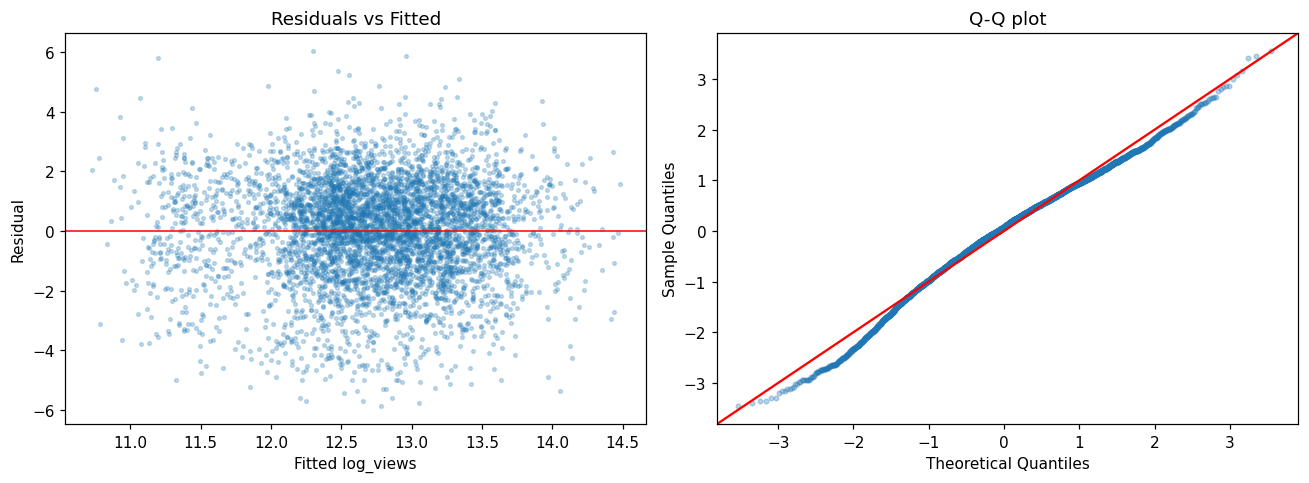

In [10]:
fitted = ols.fittedvalues
resid = ols.resid

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].scatter(fitted, resid, s=6, alpha=0.25)
ax[0].axhline(0, color="red", lw=1)
ax[0].set_xlabel("Fitted log_views"); ax[0].set_ylabel("Residual")
ax[0].set_title("Residuals vs Fitted")

sm.qqplot(resid, line="45", fit=True, ax=ax[1], markersize=3, alpha=0.3)
ax[1].set_title("Q-Q plot")

plt.tight_layout()
plt.savefig(OUT / "fig_lr_residuals.png", bbox_inches="tight")
plt.show()

### 검증 4 — R² / RMSE (test, 시간 split)

In [11]:
def evaluate(model, data, label):
    pred = model.predict(data)
    y = data["log_views"]
    r2 = r2_score(y, pred)
    rmse = np.sqrt(mean_squared_error(y, pred))
    print(f"[{label}]  R2 = {r2:.4f}   RMSE = {rmse:.4f}")
    return r2, rmse

evaluate(ols, train, "TRAIN")
evaluate(ols, test,  "TEST ")

[TRAIN]  R2 = 0.1126   RMSE = 1.6997
[TEST ]  R2 = -1.2830   RMSE = 1.8445


(-1.282998940306323, np.float64(1.84454279116444))

## 3단계 — 카테고리별 분리 회귀 (H4 후반부)
Top3 카테고리 **각각 별도 OLS 적합** → 같은 제목 변수의 계수 방향·크기·유의성이 그룹마다 다른지 비교.
(계획서 가정: Gaming / Music / Film & Animation — 실제 Top3는 빈도 기준 자동 선택)

In [12]:
top3 = df["category"].value_counts().head(3).index.tolist()
print("Top3 categories:", top3)

sub_formula = ("log_views ~ title_len + word_count + caps_ratio + exclaim_cnt + "
               "question_cnt + has_number + has_bracket + tag_cnt + "
               "C(hour_bin, Treatment(reference='18-23')) + C(publish_weekday)")

models = {}
for cat in top3:
    d = model_df[model_df["category"] == cat]
    models[cat] = smf.ols(sub_formula, data=d).fit()
    print(f"{cat:20s} n={len(d):5d}  R2={models[cat].rsquared:.3f}")

Top3 categories: ['Entertainment', 'Music', 'Howto & Style']
Entertainment        n= 1599  R2=0.076
Music                n=  792  R2=0.075
Howto & Style        n=  590  R2=0.082


### 계수 비교표 — 제목 변수의 카테고리별 효과

In [13]:
def star(p): return "*" if p < 0.05 else ""

rows = []
for feat in title_feats:
    row = {"feature": feat}
    for cat in top3:
        m = models[cat]
        if feat in m.params.index:
            row[cat] = f"{m.params[feat]:.3f}{star(m.pvalues[feat])}"
        else:
            row[cat] = "-"
    rows.append(row)
compare = pd.DataFrame(rows).set_index("feature")
compare.to_csv(OUT / "coef_comparison_top3.csv")
print("(* = p < 0.05)")
compare

(* = p < 0.05)


,Entertainment,Music,Howto & Style
feature,,,
title_len,-0.005,-0.014,-0.002
word_count,-0.027,0.066,0.027
caps_ratio,0.590*,0.875,0.689*
exclaim_cnt,0.158,-0.313,0.204
question_cnt,-0.146,-0.210,0.254
has_number,0.112,-0.492*,-0.236
has_bracket,0.488*,0.388*,0.480
tag_cnt,0.019*,0.016*,0.001


---
### 해석 메모 (실행 후 작성)
- 유의한 제목 변수 / 방향:
- VIF 결과 (title_len↔word_count 처리 여부):
- 잔차 등분산·정규성:
- 카테고리별 계수 차이 (H4 검증):

### 다음 반복 (4단계, 별도)
1. 감성 파생변수(VADER) 추가 → 객관 지표 한계 보완
2. ET 시간 변환 → UTC vs 미국 체감 시간 어긋남 정식화